In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# load dataset
df = pd.read_csv('../data/data.csv', encoding='latin1')

In [8]:
# First 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
# Dataset shape
df.shape
# Dataset information
df.info()
# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Total sales calculation
df['TotalSales'] = df['Quantity'] * df['UnitPrice']
# Verify
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [11]:
# Total revenue

total_revenue = df['TotalSales'].sum()
print('Total Revenue:', round(total_revenue, 2))

Total Revenue: 9747747.93


In [12]:
# Top products
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64


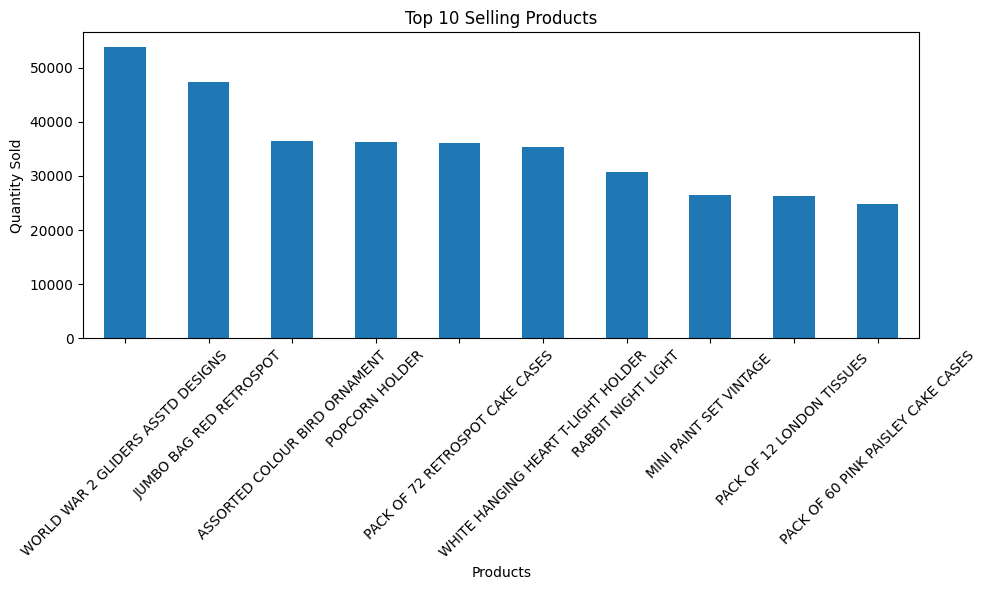

In [14]:
#Top 10 Selling Products
plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../dashboard/top_products.png')

plt.show()

In [15]:
#Revenue By Country
country_revenue = (
    df.groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(country_revenue)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalSales, dtype: float64


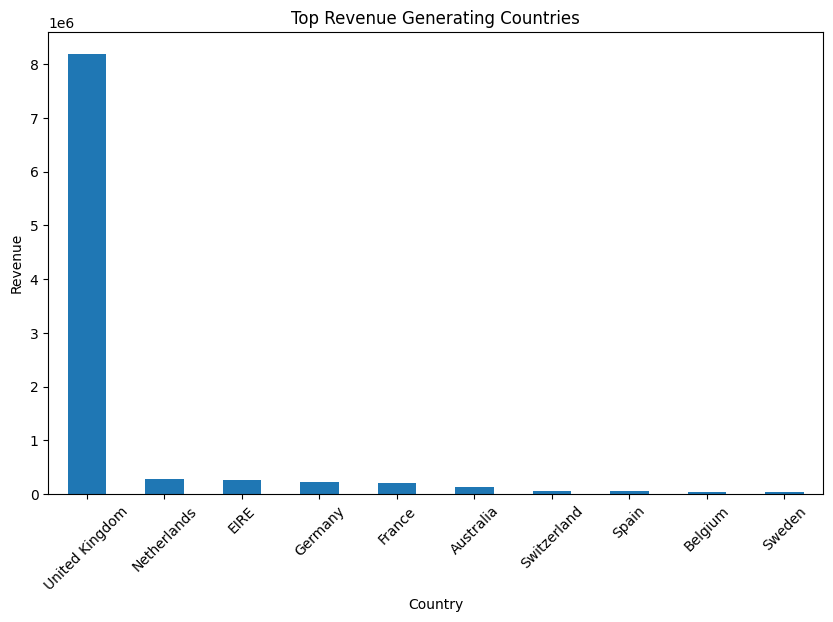

In [17]:
#Chart 2 — Revenue By Country
plt.figure(figsize=(10,6))

country_revenue.plot(kind='bar')

plt.title('Top Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout
plt.savefig('../dashboard/country_revenue.png')

plt.show()

In [18]:
#Top Customers By Spending
customer_spending = (
    df.groupby('CustomerID')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(customer_spending)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: TotalSales, dtype: float64


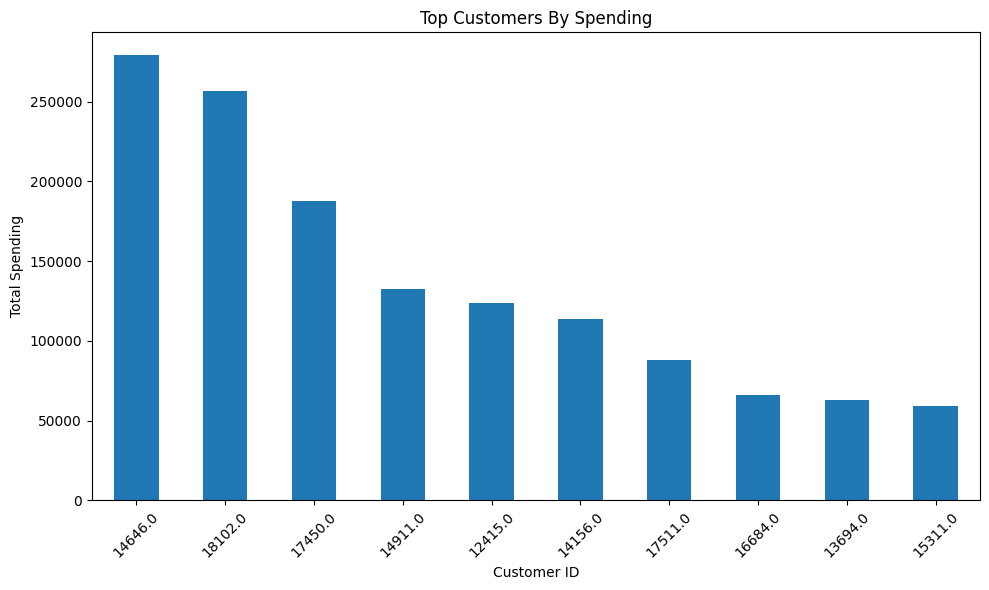

In [19]:
#Chart 3 — Top Customers
plt.figure(figsize=(10,6))

customer_spending.plot(kind='bar')

plt.title('Top Customers By Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../dashboard/top_customers.png')

plt.show()

In [20]:
#Monthly Revenue Trend
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create month column
df['Month'] = df['InvoiceDate'].dt.month
monthly_sales = (
    df.groupby('Month')['TotalSales']
    .sum()
)
print(monthly_sales)

Month
1      560000.260
2      498062.650
3      683267.080
4      493207.121
5      723333.510
6      691123.120
7      681300.111
8      682680.510
9     1019687.622
10    1070704.670
11    1461756.250
12    1182625.030
Name: TotalSales, dtype: float64


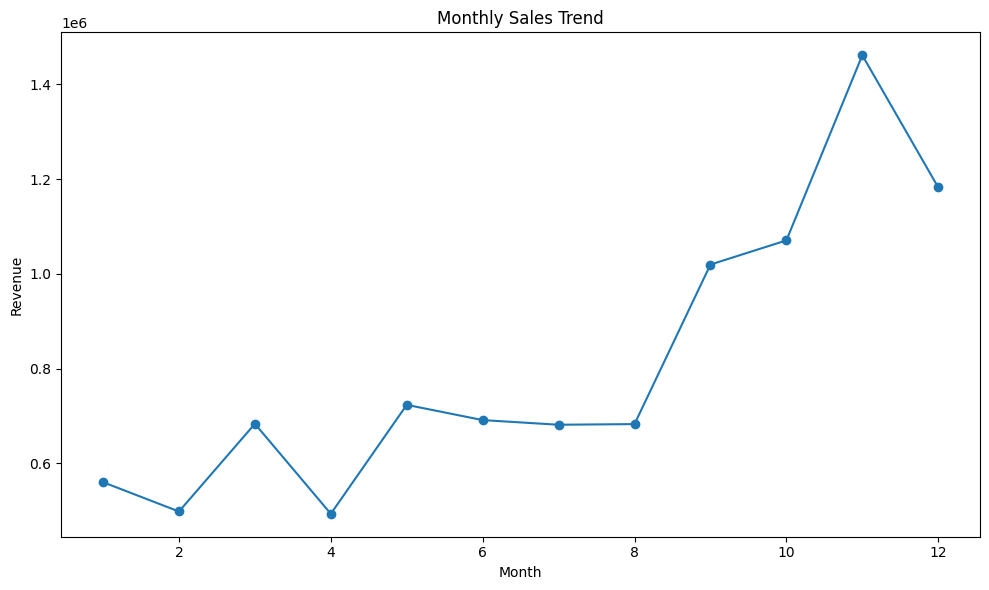

In [21]:
#Chart 4 — Monthly Sales Trend
plt.figure(figsize=(10,6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.tight_layout()

plt.savefig('../dashboard/monthly_sales.png')

plt.show()

In [22]:
#Most Expensive Products
expensive_products = (
    df.groupby('Description')['UnitPrice']
    .max()
    .sort_values(ascending=False)
    .head(10)
)
print(expensive_products)

Description
Manual                            38970.00
AMAZON FEE                        17836.46
Adjust bad debt                   11062.06
POSTAGE                            8142.75
DOTCOM POSTAGE                     4505.17
Discount                           1867.86
CRUK Commission                    1100.44
Bank Charges                       1050.15
PICNIC BASKET WICKER 60 PIECES      649.50
SAMPLES                             570.00
Name: UnitPrice, dtype: float64


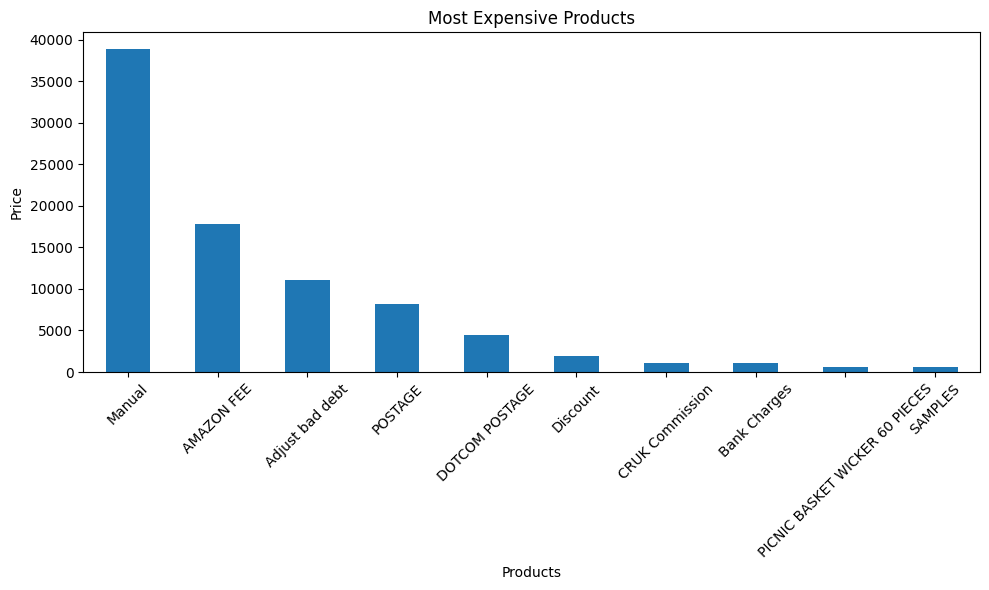

In [23]:
#Chart 5 — Most Expensive Products
plt.figure(figsize=(10,6))

expensive_products.plot(kind='bar')

plt.title('Most Expensive Products')
plt.xlabel('Products')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../dashboard/expensive_products.png')

plt.show()

In [24]:
#Average Order 
average_order = df['TotalSales'].mean()
print('Average Order Value:', round(average_order, 2))

Average Order Value: 17.99


In [25]:
#Total Orders
total_orders = df['InvoiceNo'].nunique()
print('Total Orders:', total_orders)

Total Orders: 25900


In [26]:
#Export Cleaned Dataset
df.to_csv('../data/cleaned_data.csv', index=False)